#**🚨 Public Information Prioritizer Using Natural Language Processing**

**Mini NLP Project**

**Objective:**  
To develop an NLP-based system that analyzes public information and determines its category, crisis type, urgency, action requirement, promotional status, and final priority.

**Techniques Used:**
- Text Preprocessing
- TF-IDF Feature Extraction
- Logistic Regression
- Multinomial Naive Bayes
- Rule-Based NLP
- Confusion Matrix Evaluation

**Datasets:**
- News Article Categories Dataset
- Crisis Dataset

**1. Problem Statement**

Large amounts of public information such as news articles, emergency alerts, government notices, educational announcements, job notifications, and promotional messages are generated every day.

It can be difficult for people to quickly identify:

- What type of information they are reading
- Whether it is related to a crisis
- How urgent the information is
- Whether any action is required
- Whether the message is promotional
- Which information should receive higher priority

### Proposed Solution

This project develops a **Public Information Prioritizer using Natural Language Processing (NLP)**.

The system accepts a text message, news article, alert, or public notice and analyzes it using a combination of **machine learning and rule-based NLP techniques**.

The system produces:

1. Information category
2. Crisis status and crisis type
3. Urgency level
4. Action-required status
5. Promotional status
6. Final priority level

**2. Objectives**

The main objectives of this project are:

1. To preprocess and clean textual public information using NLP techniques.
2. To classify news articles into their respective categories using machine learning.
3. To identify the type of crisis mentioned in emergency-related information.
4. To estimate the urgency level of a message using rule-based NLP.
5. To determine whether an action is required from the reader.
6. To identify promotional or advertisement-related content.
7. To combine these outputs to calculate a final priority level.
8. To evaluate the machine learning components using accuracy, precision, recall, F1-score, and confusion matrices.
9. To compare different traditional machine learning approaches and select the better-performing model.

**3. Methodology**

The proposed system follows a hybrid NLP architecture combining **machine learning classification** with **rule-based NLP techniques**.

**Overall Workflow **

**Public Information**  
↓  
**Text Preprocessing**  
↓  
**Crisis / Promotion Detection**  
↓  
**Information Classification**  
↓  
**Urgency Detection**  
↓  
**Action Detection**  
↓  
**Priority Calculation**  
↓  
**Final Analysis Result**

**Machine Learning Components**

- **TF-IDF** is used to convert text into numerical features.
- **Logistic Regression** is used for news-category classification.
- **Logistic Regression** is also used for crisis-type classification.
- **Multinomial Naive Bayes** is evaluated as a comparison model for news classification.

**Rule-Based Components**

Rule-based NLP is used for:

- Crisis keyword detection
- Urgency detection
- Action-required detection
- Promotional-content detection
- Final priority calculation

This hybrid approach makes the system both **data-driven and interpretable**.

**4. Datasets**

This project uses two datasets to build different components of the Public Information Prioritizer.

**Dataset 1 — News Article Categories**

The News Article Categories dataset contains **6,877 records** with the following fields:

- `category` — target class
- `title` — news article title
- `body` — news article content

The dataset contains **14 news categories**:

- ARTS & CULTURE
- BUSINESS
- COMEDY
- CRIME
- EDUCATION
- ENTERTAINMENT
- ENVIRONMENT
- MEDIA
- POLITICS
- RELIGION
- SCIENCE
- SPORTS
- TECH
- WOMEN

After removing **28 exact duplicate records**, **6,849 records** were used for the final classification experiment.

**Dataset 2 — Crisis Dataset**

The Crisis dataset contains **2,345 records** and includes:

- `tweet_id`
- `user_id`
- `timestamp`
- `text`
- `crisis_type`
- `location`
- `relevance_label`
- `urgency_label`
- `informative_label`

The dataset contains **7 crisis types**:

- Earthquake
- Explosion
- Fire
- Flood
- Hurricane
- Landslide
- Pandemic

### Dataset Limitation

The crisis dataset contains a high number of repeated text entries. Therefore, a **group-aware train/test split** was used for crisis-type classification to prevent the same text from appearing in both training and testing sets.

The urgency labels also showed substantial inconsistency across repeated texts. Therefore, an ML-based urgency classifier was evaluated experimentally but was **not selected for the final system**.

**5. News Article Category Classification**

The first machine learning component classifies public information into one of the 14 news categories.

The following steps are performed:

1. Load and inspect the dataset
2. Explore the category distribution
3. Combine title and body text
4. Clean and preprocess the text
5. Remove exact duplicate records
6. Split the data into training and testing sets
7. Convert text into TF-IDF features
8. Train classification models
9. Compare model performance
10. Evaluate the selected model using a confusion matrix

In [119]:
import pandas as pd
import numpy as np
import re
import csv

print("Libraries imported successfully!")

Libraries imported successfully!


In [120]:
import os

print(os.listdir("/content"))

['.config', 'crisis.csv', 'news_category_confusion_matrix.png', 'news-article-categories.csv', 'crisis_type_model.pkl', 'news_category_model.pkl', 'crisis_type_tfidf.pkl', 'news_category_tfidf.pkl', 'crisis_type_confusion_matrix.png', 'sample_data']


In [121]:
import csv
import pandas as pd

file_path = "/content/news-article-categories.csv"

rows = []

with open(file_path, "r", encoding="utf-8", errors="replace", newline="") as f:
    reader = csv.reader(f)

    for row in reader:
        if len(row) == 3:
            rows.append(row)

news_df = pd.DataFrame(
    rows[1:],
    columns=rows[0]
)

print("Dataset loaded successfully!")
print("Shape:", news_df.shape)
print("\nColumns:", news_df.columns.tolist())

Dataset loaded successfully!
Shape: (6877, 3)

Columns: ['category', 'title', 'body']


In [122]:
print("First 5 rows:")
display(news_df.head())

print("\nMissing values:")
print(news_df.isnull().sum())

print("\nNumber of categories:")
print(news_df["category"].nunique())

print("\nCategory distribution:")
print(news_df["category"].value_counts())

First 5 rows:


,category,title,body
0,ARTS & CULTURE,Modeling Agencies Enabled Sexual Predators For...,"In October 2017, Carolyn Kramer received a dis..."
1,ARTS & CULTURE,Actor Jeff Hiller Talks “Bright Colors And Bol...,This week I talked with actor Jeff Hiller abou...
2,ARTS & CULTURE,New Yorker Cover Puts Trump 'In The Hole' Afte...,The New Yorker is taking on President Donald T...
3,ARTS & CULTURE,Man Surprises Girlfriend By Drawing Them In Di...,"Kellen Hickey, a 26-year-old who lives in Huds..."
4,ARTS & CULTURE,This Artist Gives Renaissance-Style Sculptures...,There’s something about combining the traditio...



Missing values:
category    0
title       0
body        0
dtype: int64

Number of categories:
14

Category distribution:
category
ARTS & CULTURE    1002
BUSINESS           501
ENTERTAINMENT      501
RELIGION           501
POLITICS           501
ENVIRONMENT        501
WOMEN              501
TECH               501
SPORTS             501
EDUCATION          490
COMEDY             380
SCIENCE            350
MEDIA              347
CRIME              300
Name: count, dtype: int64


In [123]:
# Fill any missing body values
news_df["body"] = news_df["body"].fillna("")

# Combine title and body
news_df["combined_text"] = (
    news_df["title"].astype(str) + " " +
    news_df["body"].astype(str)
)

print("Combined text created successfully!")
print(news_df[["category", "combined_text"]].head())

Combined text created successfully!
         category                                      combined_text
0  ARTS & CULTURE  Modeling Agencies Enabled Sexual Predators For...
1  ARTS & CULTURE  Actor Jeff Hiller Talks “Bright Colors And Bol...
2  ARTS & CULTURE  New Yorker Cover Puts Trump 'In The Hole' Afte...
3  ARTS & CULTURE  Man Surprises Girlfriend By Drawing Them In Di...
4  ARTS & CULTURE  This Artist Gives Renaissance-Style Sculptures...


In [124]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# Apply text cleaning
news_df["clean_text"] = news_df["combined_text"].apply(clean_text)

print("Text preprocessing completed!")
print("\nOriginal:")
print(news_df["combined_text"].iloc[0][:300])

print("\nCleaned:")
print(news_df["clean_text"].iloc[0][:300])

Text preprocessing completed!

Original:
Modeling Agencies Enabled Sexual Predators For Years, Former Agent Says In October 2017, Carolyn Kramer received a disturbing phone call. The former modeling agent listened intently as a model she used to represent told her that a famous French photographer, who still shoots for top publications, ra

Cleaned:
modeling agencies enabled sexual predators for years, former agent says in october 2017, carolyn kramer received a disturbing phone call. the former modeling agent listened intently as a model she used to represent told her that a famous french photographer, who still shoots for top publications, ra


In [125]:
# Check duplicates before removing them
duplicates = news_df.duplicated(subset=["title", "body"]).sum()

print("Duplicate articles found:", duplicates)

# Remove exact duplicate articles
news_df = news_df.drop_duplicates(
    subset=["title", "body"]
).reset_index(drop=True)

print("Dataset shape after removing duplicates:", news_df.shape)

print("Number of categories:", news_df["category"].nunique())

Duplicate articles found: 28
Dataset shape after removing duplicates: (6849, 5)
Number of categories: 14


In [126]:
from sklearn.model_selection import train_test_split

# Input text
X = news_df["clean_text"]

# Target category
y = news_df["category"]

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training classes:", y_train.nunique())
print("Testing classes:", y_test.nunique())

Training samples: 5479
Testing samples: 1370
Training classes: 14
Testing classes: 14


In [128]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Learn vocabulary from training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using the same vocabulary
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF completed successfully!")
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

TF-IDF completed successfully!
Training TF-IDF shape: (5479, 20000)
Testing TF-IDF shape: (1370, 20000)


In [129]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create Logistic Regression model
category_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
category_model.fit(X_train_tfidf, y_train)

# Predict test data
y_pred = category_model.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", round(accuracy, 4))

# Detailed evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.7927

Classification Report:
                precision    recall  f1-score   support

ARTS & CULTURE       0.74      0.96      0.84       201
      BUSINESS       0.75      0.69      0.72       100
        COMEDY       0.71      0.64      0.68        76
         CRIME       0.81      0.78      0.80        60
     EDUCATION       0.86      0.85      0.85        98
 ENTERTAINMENT       0.74      0.66      0.70       100
   ENVIRONMENT       0.82      0.89      0.85        96
         MEDIA       0.85      0.59      0.70        69
      POLITICS       0.76      0.81      0.79       100
      RELIGION       0.87      0.88      0.88       100
       SCIENCE       0.92      0.79      0.85        70
        SPORTS       0.95      0.87      0.91       100
          TECH       0.80      0.72      0.76       100
         WOMEN       0.68      0.70      0.69       100

      accuracy                           0.79      1370
     macro avg       0.80      0.77      

In [130]:
from sklearn.metrics import f1_score

print("y_test size:", len(y_test))
print("y_pred size:", len(y_pred))
print("News accuracy:", accuracy_score(y_test, y_pred))
print("News macro F1:", f1_score(y_test, y_pred, average="macro"))

y_test size: 1370
y_pred size: 1370
News accuracy: 0.7927007299270074
News macro F1: 0.7849466383894022


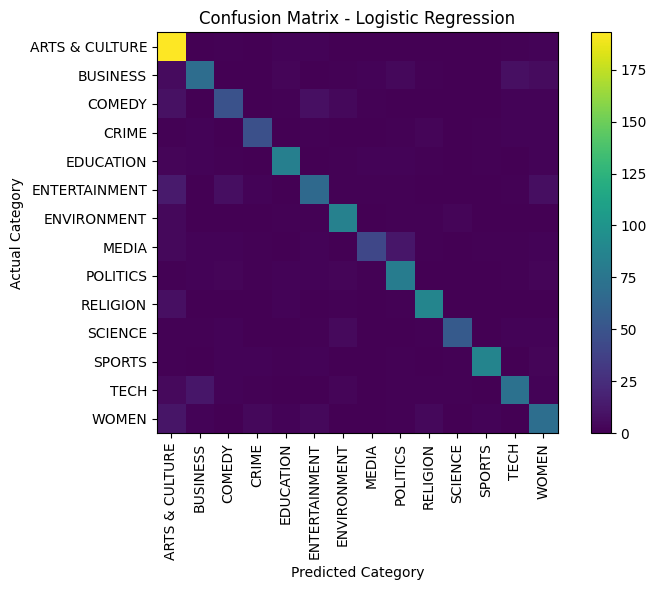

In [131]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Get category names
categories = sorted(y_test.unique())

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=categories)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm)

plt.xticks(
    range(len(categories)),
    categories,
    rotation=90
)

plt.yticks(
    range(len(categories)),
    categories
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Confusion Matrix - Logistic Regression")

plt.colorbar()

plt.tight_layout()
plt.show()

In [132]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Create Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_tfidf, y_train)

# Predict test data
nb_pred = nb_model.predict(X_test_tfidf)

# Calculate accuracy
nb_accuracy = accuracy_score(y_test, nb_pred)

print("Multinomial Naive Bayes Accuracy:", round(nb_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, nb_pred))

Multinomial Naive Bayes Accuracy: 0.6131

Classification Report:
                precision    recall  f1-score   support

ARTS & CULTURE       0.36      0.99      0.53       201
      BUSINESS       0.67      0.55      0.60       100
        COMEDY       0.82      0.49      0.61        76
         CRIME       0.89      0.65      0.75        60
     EDUCATION       0.80      0.76      0.78        98
 ENTERTAINMENT       0.79      0.19      0.31       100
   ENVIRONMENT       0.85      0.57      0.68        96
         MEDIA       0.86      0.17      0.29        69
      POLITICS       0.65      0.86      0.74       100
      RELIGION       0.92      0.65      0.76       100
       SCIENCE       0.95      0.26      0.40        70
        SPORTS       0.93      0.75      0.83       100
          TECH       0.81      0.58      0.67       100
         WOMEN       0.59      0.48      0.53       100

      accuracy                           0.61      1370
     macro avg       0.78      0.57  

In [133]:
nb_macro_f1 = f1_score(y_test, nb_pred, average="macro")

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("Naive Bayes Macro F1:", nb_macro_f1)

Naive Bayes Accuracy: 0.6131386861313869
Naive Bayes Macro F1: 0.606769191282867


### 5.2 Model Comparison

Two traditional machine learning classifiers were evaluated using the same TF-IDF representation:

- Logistic Regression
- Multinomial Naive Bayes

Both models were trained and tested using the same training and testing data.

The models are compared using accuracy and macro F1-score. Macro F1-score gives equal importance to all 14 news categories.

Logistic Regression achieved better performance and was therefore selected as the final model for news-category classification.

In [134]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        accuracy,
        nb_accuracy
    ],
    "Macro F1": [
        f1_score(y_test, y_pred, average="macro"),
        nb_macro_f1
    ]
})

display(comparison_df)

print("\nSelected Model: Logistic Regression")
print("Reason: It achieved higher accuracy and macro F1-score.")

,Model,Accuracy,Macro F1
0,Logistic Regression,0.792701,0.784947
1,Multinomial Naive Bayes,0.613139,0.606769



Selected Model: Logistic Regression
Reason: It achieved higher accuracy and macro F1-score.


**6. Crisis Information Classification**

The second dataset is used to identify whether public information is related to a crisis and, if so, determine the specific crisis type.

The crisis classification component follows these steps:

1. Load and explore the crisis dataset
2. Examine crisis-type and other label distributions
3. Check duplicate and conflicting text labels
4. Preprocess the crisis text
5. Apply a group-aware train/test split
6. Extract TF-IDF features
7. Train a Logistic Regression classifier
8. Evaluate the model using accuracy, precision, recall, F1-score, and confusion matrix

In [135]:
# Load the crisis dataset

crisis_df = pd.read_csv("/content/crisis.csv")

print("Crisis dataset loaded successfully!")

print("Shape:", crisis_df.shape)

print("\nColumns:")
print(crisis_df.columns.tolist())

print("\nFirst 5 rows:")
display(crisis_df.head())


Crisis dataset loaded successfully!
Shape: (2345, 9)

Columns:
['tweet_id', 'user_id', 'timestamp', 'text', 'crisis_type', 'location', 'relevance_label', 'urgency_label', 'informative_label']

First 5 rows:


,tweet_id,user_id,timestamp,text,crisis_type,location,relevance_label,urgency_label,informative_label
0,1,u2824,2024-02-07 11:09,Power out and trees down everywhere in Texas. ...,Hurricane,Texas,1,Low,Not informative
1,2,u1409,2023-12-13 14:47,Massive explosion reported at the chemical pla...,Explosion,Texas,1,Medium,Not informative
2,3,u5506,2023-02-10 20:40,Massive earthquake reported near California. B...,Earthquake,California,0,High,Informative
3,4,u5012,2024-04-08 15:58,Massive explosion reported at the chemical pla...,Explosion,Florida,1,High,Unsure
4,5,u4657,2023-01-07 21:09,"New variant detected in Brazil, authorities is...",Pandemic,Brazil,0,Medium,Not informative


In [136]:
print("Crisis Type Distribution:")
print(crisis_df["crisis_type"].value_counts())

print("\nUrgency Distribution:")
print(crisis_df["urgency_label"].value_counts())

print("\nRelevance Distribution:")
print(crisis_df["relevance_label"].value_counts())

print("\nInformative Distribution:")
print(crisis_df["informative_label"].value_counts())

print("\nMissing Values:")
print(crisis_df.isnull().sum())

Crisis Type Distribution:
crisis_type
Pandemic      370
Explosion     361
Landslide     330
Flood         327
Hurricane     324
Fire          320
Earthquake    313
Name: count, dtype: int64

Urgency Distribution:
urgency_label
Medium    796
High      795
Low       754
Name: count, dtype: int64

Relevance Distribution:
relevance_label
0    1201
1    1144
Name: count, dtype: int64

Informative Distribution:
informative_label
Not informative    816
Unsure             784
Informative        745
Name: count, dtype: int64

Missing Values:
tweet_id             0
user_id              0
timestamp            0
text                 0
crisis_type          0
location             0
relevance_label      0
urgency_label        0
informative_label    0
dtype: int64


**6.1 Data Quality and Duplicate Analysis**

Before training the crisis classifier, duplicate text entries and label consistency were examined.

This step is important because repeated text can cause data leakage if identical texts are randomly divided between training and testing sets.

The analysis also checks whether the same text is associated with different crisis types, urgency labels, or relevance labels.

In [137]:
# Check duplicate text
duplicate_texts = crisis_df["text"].duplicated().sum()

print("Duplicate text rows:", duplicate_texts)

# Check whether the same text has different crisis types
crisis_type_conflicts = (
    crisis_df.groupby("text")["crisis_type"]
    .nunique()
)

# Check whether the same text has different urgency labels
urgency_conflicts = (
    crisis_df.groupby("text")["urgency_label"]
    .nunique()
)

# Check whether the same text has different relevance labels
relevance_conflicts = (
    crisis_df.groupby("text")["relevance_label"]
    .nunique()
)

print(
    "Texts with conflicting crisis types:",
    (crisis_type_conflicts > 1).sum()
)

print(
    "Texts with conflicting urgency labels:",
    (urgency_conflicts > 1).sum()
)

print(
    "Texts with conflicting relevance labels:",
    (relevance_conflicts > 1).sum()
)

Duplicate text rows: 2135
Texts with conflicting crisis types: 0
Texts with conflicting urgency labels: 210
Texts with conflicting relevance labels: 208


**6.2 Crisis Text Preprocessing**

The crisis text is cleaned before feature extraction and classification.

The preprocessing includes:

- Converting text to lowercase
- Removing URLs
- Removing user mentions
- Removing unnecessary extra spaces

The cleaned text is then used for TF-IDF feature extraction and machine learning.

In [138]:
# Make sure crisis text is treated as string
crisis_df["text"] = crisis_df["text"].astype(str)

# Clean crisis text
def clean_crisis_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

crisis_df["clean_text"] = crisis_df["text"].apply(clean_crisis_text)

print("Crisis text preprocessing completed!")

print("\nOriginal text:")
print(crisis_df["text"].iloc[0])

print("\nCleaned text:")
print(crisis_df["clean_text"].iloc[0])

Crisis text preprocessing completed!

Original text:
Power out and trees down everywhere in Texas. This hurricane is no joke.

Cleaned text:
power out and trees down everywhere in texas. this hurricane is no joke.


**6.3 Group-Aware Train/Test Split**

The crisis dataset contains many repeated text entries. A random train/test split could place the same text in both sets and lead to data leakage.Therefore, a group-aware split is used, where identical texts are kept within the same group.This ensures that the model is evaluated on texts that were not seen in the training set.

In [139]:
from sklearn.model_selection import GroupShuffleSplit

# Input and target
X_crisis = crisis_df["clean_text"]
y_crisis = crisis_df["crisis_type"]

# Original text is used as the group
# This keeps identical texts together
groups = crisis_df["text"]

# Group-aware train/test split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X_crisis, y_crisis, groups=groups)
)

X_crisis_train = X_crisis.iloc[train_idx]
X_crisis_test = X_crisis.iloc[test_idx]

y_crisis_train = y_crisis.iloc[train_idx]
y_crisis_test = y_crisis.iloc[test_idx]

print("Training samples:", len(X_crisis_train))
print("Testing samples:", len(X_crisis_test))

print("Training classes:", y_crisis_train.nunique())
print("Testing classes:", y_crisis_test.nunique())

# Verify that no original text appears in both sets
train_texts = set(crisis_df["text"].iloc[train_idx])
test_texts = set(crisis_df["text"].iloc[test_idx])

print("Common texts between train and test:", len(train_texts & test_texts))

Training samples: 1884
Testing samples: 461
Training classes: 7
Testing classes: 7
Common texts between train and test: 0


In [140]:
from sklearn.feature_extraction.text import TfidfVectorizer

crisis_tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_crisis_train_tfidf = crisis_tfidf.fit_transform(X_crisis_train)
X_crisis_test_tfidf = crisis_tfidf.transform(X_crisis_test)

print("Training TF-IDF shape:", X_crisis_train_tfidf.shape)
print("Testing TF-IDF shape:", X_crisis_test_tfidf.shape)

Training TF-IDF shape: (1884, 487)
Testing TF-IDF shape: (461, 487)


**6.4 Crisis Type Classification**

TF-IDF features are used to represent the cleaned crisis-related text numerically.A Logistic Regression classifier is then trained to identify the type of crisis.

The model classifies the text into seven crisis categories:

- Earthquake
- Explosion
- Fire
- Flood
- Hurricane
- Landslide
- Pandemic

The model performance is evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

**6.5 Crisis Type Model Evaluation**

The crisis-type classifier is evaluated using accuracy, precision, recall, and F1-score.

A confusion matrix is also used to examine the classification results for each crisis category.

The model achieved **100% accuracy and a macro F1-score of 1.00** on the group-aware test set.

Although the result is excellent, the structured and repetitive nature of the dataset should be considered when interpreting this performance.

In [141]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

crisis_type_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

crisis_type_model.fit(
    X_crisis_train_tfidf,
    y_crisis_train
)

crisis_type_pred = crisis_type_model.predict(
    X_crisis_test_tfidf
)

crisis_type_accuracy = accuracy_score(
    y_crisis_test,
    crisis_type_pred
)

print("Crisis Type Accuracy:", round(crisis_type_accuracy, 4))
print("\nClassification Report:")
print(classification_report(y_crisis_test, crisis_type_pred))

Crisis Type Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

  Earthquake       1.00      1.00      1.00        52
   Explosion       1.00      1.00      1.00       106
        Fire       1.00      1.00      1.00        38
       Flood       1.00      1.00      1.00        84
   Hurricane       1.00      1.00      1.00        39
   Landslide       1.00      1.00      1.00        71
    Pandemic       1.00      1.00      1.00        71

    accuracy                           1.00       461
   macro avg       1.00      1.00      1.00       461
weighted avg       1.00      1.00      1.00       461



<Figure size 800x600 with 0 Axes>

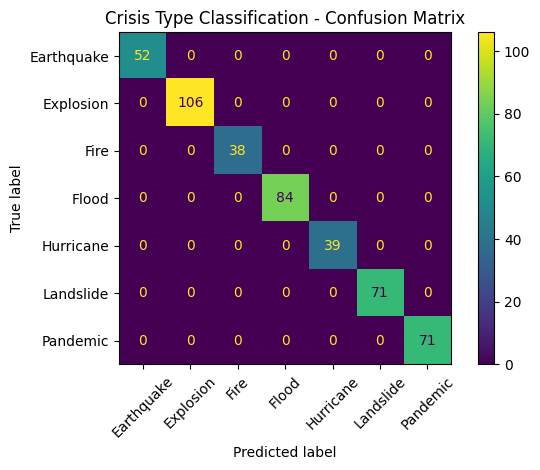

In [142]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_crisis_test,
    crisis_type_pred,
    xticks_rotation=45
)

plt.title("Crisis Type Classification - Confusion Matrix")
plt.tight_layout()
plt.show()

In [143]:
urgency_summary = (
    crisis_df.groupby("text")["urgency_label"]
    .agg(["count", "nunique", lambda x: x.value_counts().index[0]])
)

urgency_summary.columns = [
    "number_of_rows",
    "number_of_labels",
    "majority_label"
]

print(urgency_summary.head(10))

print("\nUnique texts:", len(urgency_summary))
print("Texts with conflicting urgency labels:",
      (urgency_summary["number_of_labels"] > 1).sum())

                                                    number_of_rows  \
text                                                                 
Aftershocks continue to rattle Brazil following...               8   
Aftershocks continue to rattle California follo...              11   
Aftershocks continue to rattle Florida followin...              11   
Aftershocks continue to rattle India following ...               6   
Aftershocks continue to rattle Japan following ...               7   
Aftershocks continue to rattle Nevada following...              12   
Aftershocks continue to rattle New York followi...              14   
Aftershocks continue to rattle Philippines foll...               6   
Aftershocks continue to rattle Texas following ...               7   
Aftershocks continue to rattle Turkey following...              11   

                                                    number_of_labels  \
text                                                                   
Aftershocks con

In [144]:
from collections import Counter

tie_count = 0
tie_examples = []

for text, labels in crisis_df.groupby("text")["urgency_label"]:
    counts = Counter(labels)
    max_count = max(counts.values())
    winners = [label for label, count in counts.items() if count == max_count]

    if len(winners) > 1:
        tie_count += 1
        if len(tie_examples) < 10:
            tie_examples.append((text[:80], dict(counts), winners))

print("Texts with tied majority labels:", tie_count)

print("\nExamples of ties:")
for example in tie_examples:
    print(example)

Texts with tied majority labels: 43

Examples of ties:
('Aftershocks continue to rattle Japan following the initial quake.', {'Medium': 3, 'High': 3, 'Low': 1}, ['Medium', 'High'])
('Aftershocks continue to rattle Turkey following the initial quake.', {'Medium': 4, 'Low': 4, 'High': 3}, ['Medium', 'Low'])
('Black smoke billowing from the explosion site in New York.', {'High': 2, 'Low': 4, 'Medium': 4}, ['Low', 'Medium'])
('Black smoke billowing from the explosion site in Philippines.', {'Low': 5, 'Medium': 5, 'High': 2}, ['Low', 'Medium'])
('COVID-19 cases rising again in India. Please wear masks and stay safe.', {'Low': 2, 'Medium': 2}, ['Low', 'Medium'])
('COVID-19 cases rising again in Nevada. Please wear masks and stay safe.', {'High': 5, 'Low': 5, 'Medium': 2}, ['High', 'Low'])
('COVID-19 cases rising again in New York. Please wear masks and stay safe.', {'Medium': 6, 'High': 6, 'Low': 6}, ['Medium', 'High', 'Low'])
('Flash flood warning issued in India. Residents advised to evacu

In [145]:
# Find texts with an unambiguous majority urgency label

usable_urgency = []

for text, labels in crisis_df.groupby("text")["urgency_label"]:
    counts = labels.value_counts()

    # Keep only if there is one clear majority label
    if len(counts) == 1 or counts.iloc[0] > counts.iloc[1]:
        usable_urgency.append({
            "text": text,
            "urgency_label": counts.index[0]
        })

urgency_df = pd.DataFrame(usable_urgency)

print("Total unique texts:", crisis_df["text"].nunique())
print("Usable texts with clear majority:", len(urgency_df))
print("Excluded tied texts:",
      crisis_df["text"].nunique() - len(urgency_df))

print("\nUrgency label distribution:")
print(urgency_df["urgency_label"].value_counts())

Total unique texts: 210
Usable texts with clear majority: 167
Excluded tied texts: 43

Urgency label distribution:
urgency_label
High      58
Medium    58
Low       51
Name: count, dtype: int64


In [146]:
from sklearn.model_selection import train_test_split

X_urgency = urgency_df["text"]
y_urgency = urgency_df["urgency_label"]

X_urgency_train, X_urgency_test, y_urgency_train, y_urgency_test = train_test_split(
    X_urgency,
    y_urgency,
    test_size=0.20,
    random_state=42,
    stratify=y_urgency
)

print("Training samples:", len(X_urgency_train))
print("Testing samples:", len(X_urgency_test))
print("Training classes:", y_urgency_train.nunique())
print("Testing classes:", y_urgency_test.nunique())

Training samples: 133
Testing samples: 34
Training classes: 3
Testing classes: 3


In [147]:
urgency_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True
)

X_urgency_train_tfidf = urgency_tfidf.fit_transform(X_urgency_train)
X_urgency_test_tfidf = urgency_tfidf.transform(X_urgency_test)

print("Training TF-IDF shape:", X_urgency_train_tfidf.shape)
print("Testing TF-IDF shape:", X_urgency_test_tfidf.shape)

Training TF-IDF shape: (133, 456)
Testing TF-IDF shape: (34, 456)


**7. Urgency Classification Experiment**

The crisis dataset also contains urgency labels: Low, Medium, and High.An ML-based urgency classifier was experimentally trained using TF-IDF features and Logistic Regression.
However, the repeated text entries contained inconsistent urgency labels. Therefore, the ML model achieved only **32.35% accuracy** and a **macro F1-score of 0.30**.Since this performance was close to random classification for three classes, the ML urgency model was not selected for the final system.Instead, a transparent rule-based NLP approach was used for urgency detection.

In [148]:
urgency_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

urgency_model.fit(
    X_urgency_train_tfidf,
    y_urgency_train
)

urgency_pred = urgency_model.predict(
    X_urgency_test_tfidf
)

urgency_accuracy = accuracy_score(
    y_urgency_test,
    urgency_pred
)

print("Urgency Accuracy:", round(urgency_accuracy, 4))
print("\nClassification Report:")
print(classification_report(
    y_urgency_test,
    urgency_pred
))

Urgency Accuracy: 0.3235

Classification Report:
              precision    recall  f1-score   support

        High       0.28      0.42      0.33        12
         Low       0.25      0.10      0.14        10
      Medium       0.42      0.42      0.42        12

    accuracy                           0.32        34
   macro avg       0.31      0.31      0.30        34
weighted avg       0.32      0.32      0.31        34



**8. Rule-Based NLP Components**

Since the urgency ML experiment showed low performance, rule-based NLP techniques are used in the final system.

Keyword-based rules are used to identify:

- Crisis-related information
- Urgency level
- Whether an action is required
- Promotional or advertisement content

These rules make the system simple, transparent, and easy to interpret.

**8.1 Crisis Detection**

The system first checks whether the input text is related to a crisis.A predefined set of crisis-related keywords is used to identify terms associated with events such as earthquakes, floods, fires, hurricanes, landslides, explosions, and pandemics.If a crisis is detected, the text is passed to the crisis-type machine learning classifier.

In [149]:
crisis_keywords = [
    "earthquake",
    "aftershock",
    "explosion",
    "blast",
    "fire",
    "wildfire",
    "flood",
    "flooding",
    "hurricane",
    "cyclone",
    "landslide",
    "mudslide",
    "pandemic",
    "epidemic",
    "covid",
    "evacuate",
    "evacuation",
    "disaster",
    "rescue",
    "emergency",
    "tsunami",
    "collapse"
]

def detect_crisis(text):
    text = clean_crisis_text(text)

    for keyword in crisis_keywords:
        if keyword in text:
            return "Crisis"

    return "Not Crisis"


print(detect_crisis(
    "A powerful earthquake has struck the region."
))

print(detect_crisis(
    "The government announced a new education policy."
))

print(detect_crisis(
    "Scientists published a new study about climate change."
))

Crisis
Not Crisis
Not Crisis


**8.2 Urgency Detection**

The urgency level is determined using predefined keywords.

The system assigns three urgency levels:

- **High** — emergency or immediate-response terms are detected
- **Medium** — warning, risk, preparation, or caution-related terms are detected
- **Low** — no high- or medium-urgency terms are detected

This rule-based approach provides an interpretable urgency estimate.

In [150]:
high_urgency_words = [
    "emergency",
    "evacuate",
    "evacuation",
    "warning",
    "alert",
    "critical",
    "danger",
    "urgent",
    "immediately",
    "life-threatening",
    "rescue",
    "disaster"
]

medium_urgency_words = [
    "advisory",
    "caution",
    "risk",
    "possible",
    "expected",
    "prepare",
    "prepared",
    "monitor",
    "concern"
]

def detect_urgency(text):
    text = clean_crisis_text(text)

    high_score = sum(word in text for word in high_urgency_words)
    medium_score = sum(word in text for word in medium_urgency_words)

    if high_score >= 1:
        return "High"
    elif medium_score >= 1:
        return "Medium"
    else:
        return "Low"

print(detect_urgency(
    "Emergency warning issued. Residents must evacuate immediately."
))

print(detect_urgency(
    "Authorities issued an advisory about possible flooding."
))

print(detect_urgency(
    "Officials reported normal conditions in the region."
))

High
Medium
Low


**8.3 Action Required Detection**

The system determines whether the reader needs to take any action based on action-related keywords and phrases.

Examples include terms such as:

- evacuate
- avoid
- contact
- register
- apply
- submit
- deadline
- prepare
- follow

If an action-related term is detected, the system marks the information as **Yes**; otherwise, it marks it as **No**.

In [151]:
action_words = [
    "evacuate",
    "evacuation",
    "avoid",
    "stay away",
    "do not",
    "don't",
    "must",
    "required",
    "call",
    "contact",
    "register",
    "apply",
    "submit",
    "deadline",
    "attend",
    "report",
    "prepare",
    "wear",
    "follow",
    "leave",
    "seek"
]

def detect_action_required(text):
    text = clean_crisis_text(text)

    for phrase in action_words:
        if phrase in text:
            return "Yes"

    return "No"


print(detect_action_required(
    "Residents must evacuate immediately and stay away from the area."
))

print(detect_action_required(
    "The government announced a new education policy today."
))

Yes
No


**8.4 Promotional Content Detection**

The system identifies whether the input contains promotional or advertisement-related content.

A predefined set of promotional keywords and phrases is used, such as:

- buy
- sale
- discount
- offer
- deal
- coupon
- sponsored
- advertisement
- promotion
- limited time
- free shipping

If a promotional term is detected, the text is classified as **Advertisement/Promotion**; otherwise, it is classified as **Not Promotional**.

In [152]:
promotion_words = [
    "buy",
    "sale",
    "discount",
    "offer",
    "deal",
    "coupon",
    "shop",
    "purchase",
    "subscribe",
    "sponsored",
    "advertisement",
    "advertising",
    "promotion",
    "promo",
    "limited time",
    "free shipping"
]

def detect_promotion(text):
    text = clean_crisis_text(text)

    for phrase in promotion_words:
        if phrase in text:
            return "Advertisement/Promotion"

    return "Not Promotional"


print(detect_promotion(
    "Limited time offer! Buy now and get 50% discount."
))

print(detect_promotion(
    "Heavy rainfall warning issued across the district."
))

Advertisement/Promotion
Not Promotional


**8.5 Priority Calculation**

The final priority level is calculated by combining the detected crisis status, urgency level, action requirement, and promotional status.

The system assigns four priority levels:

- **Critical** — high-urgency crisis information requiring immediate action
- **High** — high-urgency information or medium-urgency information requiring action
- **Medium** — medium-urgency information or information requiring action
- **Low** — low-urgency information that does not require action

Promotional content is assigned a **Low** priority because it does not represent urgent public information.

In [153]:
def calculate_priority(crisis_status, urgency, action_required, promotional):

    if promotional == "Advertisement/Promotion":
        return "Low"

    if (
        crisis_status == "Crisis"
        and urgency == "High"
        and action_required == "Yes"
    ):
        return "Critical"

    if (
        urgency == "High"
        or (urgency == "Medium" and action_required == "Yes")
    ):
        return "High"

    if urgency == "Medium" or action_required == "Yes":
        return "Medium"

    return "Low"

In [154]:
calculate_priority("Crisis", "High", "Yes", "Not Promotional")

'Critical'

In [156]:
test_inputs = [
    "Flash flood warning issued. Residents must evacuate immediately.",
    "The government announced a new education policy for students.",
    "Limited time offer! Buy now and get 50% discount.",
    "Heavy rainfall is expected in the region. Residents should prepare.",
    "Scientists published a new study about climate change."
]

for text in test_inputs:
    urgency = detect_urgency(text)
    action = detect_action_required(text)
    promotion = detect_promotion(text)

    print("\nText:", text)
    print("Urgency:", urgency)
    print("Action Required:", action)
    print("Promotion:", promotion)


Text: Flash flood warning issued. Residents must evacuate immediately.
Urgency: High
Action Required: Yes
Promotion: Not Promotional

Text: The government announced a new education policy for students.
Urgency: Low
Action Required: No
Promotion: Not Promotional

Text: Limited time offer! Buy now and get 50% discount.
Urgency: Low
Action Required: No
Promotion: Advertisement/Promotion

Text: Heavy rainfall is expected in the region. Residents should prepare.
Urgency: Medium
Action Required: Yes
Promotion: Not Promotional

Text: Scientists published a new study about climate change.
Urgency: Low
Action Required: No
Promotion: Not Promotional


**9. Complete NLP Prediction Pipeline**

The complete prediction pipeline combines all the machine learning and rule-based components developed in the project.

For a given input text, the system:

1. Detects promotional content.
2. Checks whether the text is crisis-related.
3. Classifies the crisis type if a crisis is detected.
4. Classifies the news category for non-crisis, non-promotional content.
5. Determines the urgency level.
6. Detects whether an action is required.
7. Calculates the final priority level.

The final output provides a structured analysis of the input information.

In [160]:
import os

saved_files = [
    "news_category_model.pkl",
    "news_category_tfidf.pkl",
    "crisis_type_model.pkl",
    "crisis_type_tfidf.pkl"
]

for file in saved_files:
    print(file, "→", "Exists" if os.path.exists(file) else "Missing")

news_category_model.pkl → Exists
news_category_tfidf.pkl → Exists
crisis_type_model.pkl → Exists
crisis_type_tfidf.pkl → Exists


In [161]:
def predict_information(text):
    cleaned_text = clean_crisis_text(text)

    promotion = detect_promotion(cleaned_text)
    crisis_status = detect_crisis(cleaned_text)

    if crisis_status == "Crisis":
        crisis_input = crisis_tfidf.transform([cleaned_text])
        crisis_type = crisis_type_model.predict(crisis_input)[0]
        news_category = "N/A"
    elif promotion == "Advertisement/Promotion":
        crisis_type = "N/A"
        news_category = "ADVERTISEMENT"
    else:
        crisis_type = "N/A"
        news_input = tfidf.transform([cleaned_text])
        news_category = category_model.predict(news_input)[0]

    urgency = detect_urgency(cleaned_text)
    action = detect_action_required(cleaned_text)

    priority = calculate_priority(
        crisis_status,
        urgency,
        action,
        promotion
    )

    return {
        "Crisis Status": crisis_status,
        "Crisis Type": crisis_type,
        "News Category": news_category,
        "Urgency": urgency,
        "Action Required": action,
        "Promotion": promotion,
        "Final Priority": priority
    }

In [175]:
test_messages = [
    "A powerful earthquake has struck the region. Residents must evacuate immediately.",
    "Flash flood warning issued. Residents are advised to evacuate.",
    "The government announced a new education policy for college students.",
    "Limited time sale! Buy our products today and get 50% discount.",
    "Heavy rainfall is expected tomorrow. Residents should prepare for possible flooding.",
    "Scientists published a new study about climate change."
]

for i, message in enumerate(test_messages, 1):
    print(f"\nTEST {i}")
    print("Message:", message)
    print(predict_information(message))


TEST 1
Message: A powerful earthquake has struck the region. Residents must evacuate immediately.
{'Crisis Status': 'Crisis', 'Crisis Type': 'Earthquake', 'News Category': 'N/A', 'Urgency': 'High', 'Action Required': 'Yes', 'Promotion': 'Not Promotional', 'Final Priority': 'Critical'}

TEST 2
Message: Flash flood warning issued. Residents are advised to evacuate.
{'Crisis Status': 'Crisis', 'Crisis Type': 'Flood', 'News Category': 'N/A', 'Urgency': 'High', 'Action Required': 'Yes', 'Promotion': 'Not Promotional', 'Final Priority': 'Critical'}

TEST 3
Message: The government announced a new education policy for college students.
{'Crisis Status': 'Not Crisis', 'Crisis Type': 'N/A', 'News Category': 'EDUCATION', 'Urgency': 'Low', 'Action Required': 'No', 'Promotion': 'Not Promotional', 'Final Priority': 'Low'}

TEST 4
Message: Limited time sale! Buy our products today and get 50% discount.
{'Crisis Status': 'Not Crisis', 'Crisis Type': 'N/A', 'News Category': 'ADVERTISEMENT', 'Urgency':

In [166]:
test_inputs = [
    "A powerful earthquake has struck the region. Residents must evacuate immediately.",
    "Flash flood warning issued. Residents are advised to evacuate.",
    "The government announced a new education policy for college students.",
    "Limited time sale! Buy our products today and get 50% discount.",
    "Heavy rainfall is expected tomorrow. Residents should prepare for possible flooding.",
    "Scientists published a new study about climate change."
]

for i, text in enumerate(test_inputs, 1):
    print(f"\n{'='*60}")
    print(f"TEST {i}")
    print(f"Input: {text}")
    print("-" * 60)

    result = predict_information(text)

    for key, value in result.items():
        print(f"{key}: {value}")


TEST 1
Input: A powerful earthquake has struck the region. Residents must evacuate immediately.
------------------------------------------------------------
Crisis Status: Crisis
Crisis Type: Earthquake
News Category: N/A
Urgency: High
Action Required: Yes
Promotion: Not Promotional
Final Priority: Critical

TEST 2
Input: Flash flood warning issued. Residents are advised to evacuate.
------------------------------------------------------------
Crisis Status: Crisis
Crisis Type: Flood
News Category: N/A
Urgency: High
Action Required: Yes
Promotion: Not Promotional
Final Priority: Critical

TEST 3
Input: The government announced a new education policy for college students.
------------------------------------------------------------
Crisis Status: Not Crisis
Crisis Type: N/A
News Category: EDUCATION
Urgency: Low
Action Required: No
Promotion: Not Promotional
Final Priority: Low

TEST 4
Input: Limited time sale! Buy our products today and get 50% discount.
-------------------------------

In [167]:
import joblib
import os

# Save trained models and vectorizers
joblib.dump(category_model, "/content/news_category_model.pkl")
joblib.dump(tfidf, "/content/news_category_tfidf.pkl")

joblib.dump(crisis_type_model, "/content/crisis_type_model.pkl")
joblib.dump(crisis_tfidf, "/content/crisis_type_tfidf.pkl")

print("All project models saved successfully!")

print("\nSaved files:")
for file in [
    "news_category_model.pkl",
    "news_category_tfidf.pkl",
    "crisis_type_model.pkl",
    "crisis_type_tfidf.pkl"
]:
    print(file, "→", "Exists" if os.path.exists("/content/" + file) else "Missing")

All project models saved successfully!

Saved files:
news_category_model.pkl → Exists
news_category_tfidf.pkl → Exists
crisis_type_model.pkl → Exists
crisis_type_tfidf.pkl → Exists


**9.1 Interactive Prediction**

The system provides an interactive interface where the user can enter a news article, emergency alert, or public notice.

The entered text is passed through the complete NLP prediction pipeline, and the system displays:

- Crisis Status
- Crisis Type
- News Category
- Urgency
- Action Required
- Promotion Status
- Final Priority

This allows the developed NLP system to be tested with new, unseen text inputs.

In [164]:
def run_project():
    print("=" * 70)
    print("🚨 PUBLIC INFORMATION PRIORITIZER USING NLP")
    print("=" * 70)

    text = input("\nEnter a news article, alert, notice, or message:\n> ")

    if not text.strip():
        print("\nPlease enter some text.")
        return

    result = predict_information(text)

    print("\n" + "=" * 70)
    print("📊 ANALYSIS RESULT")
    print("=" * 70)

    for key, value in result.items():
        print(f"{key}: {value}")

    print("=" * 70)


print("Interactive project demo created successfully!")

Interactive project demo created successfully!


In [111]:
run_project()

🚨 PUBLIC INFORMATION PRIORITIZER USING NLP

Enter a news article, alert, notice, or message:
> Scientists have published a new study showing that climate change is affecting global temperatures.

📊 ANALYSIS RESULT
Crisis Status: Not Crisis
Crisis Type: N/A
News Category: SCIENCE
Urgency: Low
Action Required: No
Promotion: Not Promotional
Final Priority: Low


**10. Results and Evaluation**

The performance of the machine learning components is evaluated using accuracy and macro F1-score.

The results of the different experiments are compared to determine which models are suitable for the final system.

The evaluation also includes confusion matrices to understand the classification performance across individual classes.

In [168]:
# Final model evaluation summary
print("=" * 70)
print("📊 FINAL MODEL EVALUATION")
print("=" * 70)

news_accuracy = accuracy_score(y_test, y_pred)
news_macro_f1 = f1_score(y_test, y_pred, average="macro")

crisis_accuracy = accuracy_score(
    y_crisis_test,
    crisis_type_pred
)
crisis_macro_f1 = f1_score(
    y_crisis_test,
    crisis_type_pred,
    average="macro"
)

urgency_accuracy = accuracy_score(
    y_urgency_test,
    urgency_pred
)
urgency_macro_f1 = f1_score(
    y_urgency_test,
    urgency_pred,
    average="macro"
)

print("\n1. NEWS CATEGORY CLASSIFICATION")
print("Accuracy :", round(news_accuracy, 4))
print("Macro F1 :", round(news_macro_f1, 4))

print("\n2. CRISIS TYPE CLASSIFICATION")
print("Accuracy :", round(crisis_accuracy, 4))
print("Macro F1 :", round(crisis_macro_f1, 4))

print("\n3. URGENCY ML EXPERIMENT")
print("Accuracy :", round(urgency_accuracy, 4))
print("Macro F1 :", round(urgency_macro_f1, 4))

📊 FINAL MODEL EVALUATION

1. NEWS CATEGORY CLASSIFICATION
Accuracy : 0.7927
Macro F1 : 0.7849

2. CRISIS TYPE CLASSIFICATION
Accuracy : 1.0
Macro F1 : 1.0

3. URGENCY ML EXPERIMENT
Accuracy : 0.3235
Macro F1 : 0.2976


In [169]:
results = pd.DataFrame({
    "Component": [
        "News Category Classification",
        "Crisis Type Classification",
        "Urgency ML Experiment"
    ],
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Logistic Regression",
        "TF-IDF + Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        1.0000,
        0.3235
    ],
    "Macro F1": [
        0.7849,
        1.0000,
        0.2976
    ],
    "Final Decision": [
        "Selected",
        "Selected",
        "Not selected"
    ]
})

display(results)

,Component,Model,Accuracy,Macro F1,Final Decision
0,News Category Classification,TF-IDF + Logistic Regression,0.792701,0.7849,Selected
1,Crisis Type Classification,TF-IDF + Logistic Regression,1.000000,1.0000,Selected
2,Urgency ML Experiment,TF-IDF + Logistic Regression,0.323500,0.2976,Not selected


In [170]:
print("accuracy =", accuracy)
print("nb_accuracy =", nb_accuracy)

accuracy = 0.7927007299270074
nb_accuracy = 0.6131386861313869


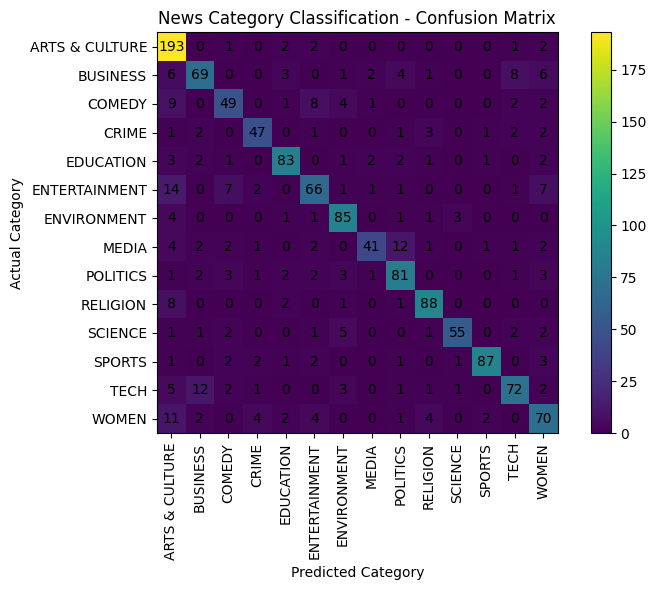

In [172]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
news_cm = confusion_matrix(y_test, y_pred, labels=category_model.classes_)

plt.figure(figsize=(8, 6))
plt.imshow(news_cm)

plt.title("News Category Classification - Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.xticks(
    range(len(category_model.classes_)),
    category_model.classes_,
    rotation=90
)

plt.yticks(
    range(len(category_model.classes_)),
    category_model.classes_
)

# Add numbers inside the matrix
for i in range(len(category_model.classes_)):
    for j in range(len(category_model.classes_)):
        plt.text(j, i, news_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

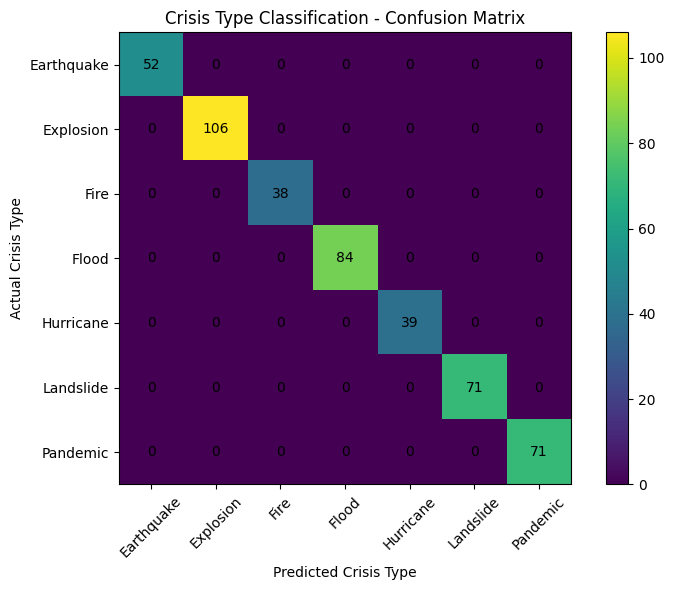

In [174]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create crisis type confusion matrix
crisis_cm = confusion_matrix(
    y_crisis_test,
    crisis_type_pred,
    labels=crisis_type_model.classes_
)

plt.figure(figsize=(8, 6))
plt.imshow(crisis_cm)

plt.title("Crisis Type Classification - Confusion Matrix")
plt.xlabel("Predicted Crisis Type")
plt.ylabel("Actual Crisis Type")

plt.xticks(
    range(len(crisis_type_model.classes_)),
    crisis_type_model.classes_,
    rotation=45
)

plt.yticks(
    range(len(crisis_type_model.classes_)),
    crisis_type_model.classes_
)

# Add values inside the matrix
for i in range(len(crisis_type_model.classes_)):
    for j in range(len(crisis_type_model.classes_)):
        plt.text(
            j,
            i,
            crisis_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

**Conclusion**

This project successfully uses NLP and machine learning to classify and prioritize public information. The hybrid approach provides useful predictions for news categories, crisis types, urgency, action requirements, and final priority, demonstrating the practical use of NLP in real-world information management.